## Contents
1. **Data Overview** <br> _Outlook on Raw Data._
2. **Data Wrangling** <br> _Data Cleaning<br>Train / Test Split<br>Statistical interference<br>Correlations<br>Data Preparation and Dimentionality Reduction._
3. **Machine Learning with sklearn** <br> _ML setup<br>Training<br>Performance (training dataset)<br>Test Sample Performance_
4. **Deep-Learning with tf.keras** <br> _Training<br>Test Sample Performance_
5. **Models Comparison** <br> _Best Model._

In [1]:
# linear algebra and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline

# Statistical interference
import scipy.stats
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Preprocessing
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler 
from sklearn.decomposition import PCA

# Estimators
from sklearn.linear_model import LinearRegression, SGDRegressor, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Pipelining
from sklearn.pipeline import make_pipeline

# Metrics
from sklearn.metrics import mean_absolute_error, r2_score

# Deep-learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1) Data Overview

## Outlook on Raw Data

In [2]:
df = pd.read_csv('/home/petewojtczak/datasets_csv/prediktiv_data.csv')
pd.set_option('display.max_columns', len(df.columns))
df.sample(7)

,id,target,feature01,feature02,feature03,feature04,feature05,feature06,feature07,feature08,feature09,feature10,feature10.1,feature11,feature12,feature13,feature14,feature15,feature16,feature17,feature18,feature19,feature20,feature21,feature22,feature23
2554,2555,121600,1.0,305.0,0,747.0,774,5,1230,4,7,1946,1,NaN,dog,red,0,NaN,bad,3,1,8,2006,1,456,1950
1474,1475,186500,2.0,470.0,0,1445.0,1445,6,1445,7,5,2004,2,NaN,NaN,red,0,NaN,good,3,1,6,2008,0,0,2004
1322,1323,184000,2.0,342.0,0,1313.0,1313,10,2495,7,7,1890,2,NaN,NaN,red,1,good,bad,5,1,12,2008,0,1182,1999
2325,2326,176500,2.0,462.0,0,935.0,955,8,1632,7,5,1998,2,NaN,NaN,red,1,bad,bad,3,1,6,2006,1,677,1998
2792,2793,220000,2.0,418.0,0,1348.0,1358,5,1358,8,5,2002,1,NaN,NaN,red,1,bad,good,1,1,6,2006,1,0,2002
818,819,323262,3.0,1138.0,0,1555.0,1680,8,1680,9,5,2009,1,NaN,NaN,red,1,good,amazing,1,1,7,2009,1,0,2009
2890,2891,171000,3.0,766.0,0,1907.0,1959,9,1959,7,5,1988,3,NaN,NaN,red,0,NaN,bad,5,2,7,2006,0,0,1989


In [3]:
df.shape

(2930, 26)

Function `columns_info()`, indicating features' basic metadata and descriptive statistics for a given df, is defined in order to facilitate analysis.

In [4]:
def columns_info(df):
    # features' basic metadata and descriptive statistics for a given df
    feature_info = {
        'feature': [],
        'dtype': [],
        'nunique': [],
        'NaN_count': [],
        'min': [],
        '25%': [],
        '50%': [],
        '75%': [],
        'max': [],
        'mean': [],
        'std_dev': []
        }

    for col in df.columns:
        feature_info['feature'].append(col)
        feature_info['dtype'].append(df[col].dtype)
        feature_info['nunique'].append(len(df[col].unique()))
        feature_info['NaN_count'].append(df[col].isna().sum())
        if df[col].dtype=='object':
            feature_info['min'].append(np.nan)
            feature_info['25%'].append(np.nan)
            feature_info['50%'].append(np.nan)
            feature_info['75%'].append(np.nan)
            feature_info['max'].append(np.nan)
            feature_info['mean'].append(np.nan)
            feature_info['std_dev'].append(np.nan)
        else:
            feature_info['min'].append(df[col].min())
            feature_info['25%'].append(df[col].quantile(0.25))
            feature_info['50%'].append(df[col].median())
            feature_info['75%'].append(df[col].quantile(0.75))
            feature_info['max'].append(df[col].max())
            feature_info['mean'].append(df[col].mean())
            feature_info['std_dev'].append(df[col].std())

    features = pd.DataFrame(feature_info)
    features.set_index('feature', inplace=True)
    features = features.sort_values(by='nunique', ascending=False)
    return features

In [5]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
features = columns_info(df)
features

,dtype,nunique,NaN_count,min,25%,50%,75%,max,mean,std_dev
feature,,,,,,,,,,
id,int64,2930,0,1.00,733.25,1465.50,2197.75,2930.00,1465.50,845.96
feature07,int64,1292,0,334.00,1126.00,1442.00,1742.75,5642.00,1499.69,505.51
feature05,int64,1083,0,334.00,876.25,1084.00,1384.00,5095.00,1159.56,391.89
feature04,float64,1059,1,0.00,793.00,990.00,1302.00,6110.00,1051.61,440.62
target,int64,1032,0,12789.00,129500.00,160000.00,213500.00,755000.00,180796.06,79886.69
feature22,int64,635,0,0.00,0.00,0.00,703.75,2065.00,335.46,428.40
feature02,float64,604,1,0.00,320.00,480.00,576.00,1488.00,472.82,215.05
feature10,int64,118,0,1872.00,1954.00,1973.00,2001.00,2010.00,1971.36,30.25
feature23,int64,61,0,1950.00,1965.00,1993.00,2004.00,2010.00,1984.27,20.86


# 2) Data Wrangling

## Data Cleaning

In [6]:
df.shape

(2930, 26)

`'feature03'` exhibits suspicious distribution, according to dataframe **features**. 

In [7]:
features.loc['feature03'].to_frame().T

,dtype,nunique,NaN_count,min,25%,50%,75%,max,mean,std_dev
feature03,int64,14,0,0.00,0.00,0.00,0.00,800.00,2.24,35.60


In [8]:
df.feature03.value_counts()

0      2917
144       1
228       1
368       1
444       1
480       1
512       1
576       1
648       1
738       1
800       1
519       1
555       1
561       1
Name: feature03, dtype: int64

In [9]:
df.drop('feature03', axis=1, inplace=True)

Some features are found to be either sparse (`'feature11'`, `'feature12'`) or having redundant role of index (`'id'`) and are therefore excluded.

In [10]:
# redundant features exclusion
df.drop(columns=['id', 'feature11', 'feature12'], inplace=True)

Two cases are present in the data - either a single missing value per feature or overpresence of missing values (`'feature15'`). In the first case rows are removed, while in case of `'feature15'`, we create a category 'NA'.  

In [11]:
# missing values
for col in df.columns:
    if (df[col].isnull().sum() == 1):
        df.drop(df.loc[pd.isna(df[col])].index, inplace=True)
df['feature15'] = df['feature15'].fillna('NA')

Duplicates are dropped as well.

In [12]:
# duplicates removal
print('No. of duplicates excluded:')
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

No. of duplicates excluded:
4


### Features' type identification (continous, ordinal, nominal)

In [13]:
features = columns_info(df)

Since there is no contextual information about our features, we will rely on 'dtype', 'nunique', and distributions to classify features as continuous, ordinal, or nominal. For numeric features, 'nunique' threshold is applied to distinguish between continuous and ordinal type. Non-numeric features are initially assumed to be nominal, though this assumption is subsequently revised (see values observed in `'feature15'` and `'feature16'`).

In [14]:
pd.set_option('mode.chained_assignment', None)
# We will assume numeric features with more than 15 nunique to be continous
continous_condition = ((features['dtype'] == 'int64') | (features['dtype'] == 'float64')) & (features['nunique'] > 15)
features['continous'] = np.where(continous_condition, True, False)
# We will assume numeric features with less than 15 nunique to be ordinal
ordinal_condition = ((features['dtype'] == 'int64') | (features['dtype'] == 'float64')) & (features['nunique'] < 15)
features['ordinal'] = np.where(ordinal_condition, True, False)
# We will, initially, assume non-numeric features to be nominal
nominal_condition = (features['dtype'] == 'object')
features['nominal'] = np.where(nominal_condition, True, False)

**Nominal Features Revision**

In [15]:
features[features.nominal].sort_index().index.values

array(['feature13', 'feature15', 'feature16'], dtype=object)

Let's have a closer look at our initial nominal features.

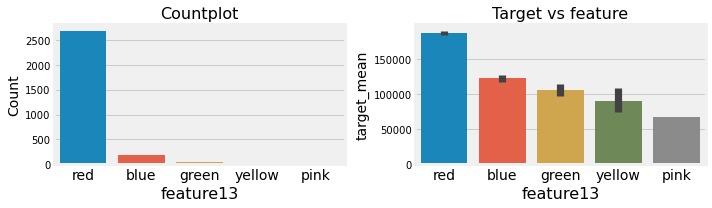

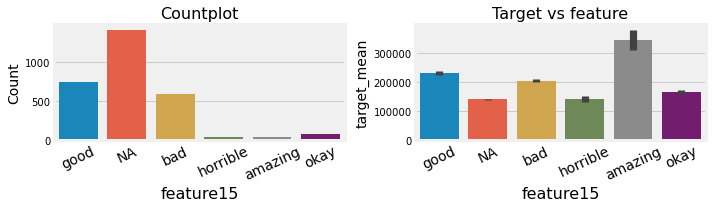

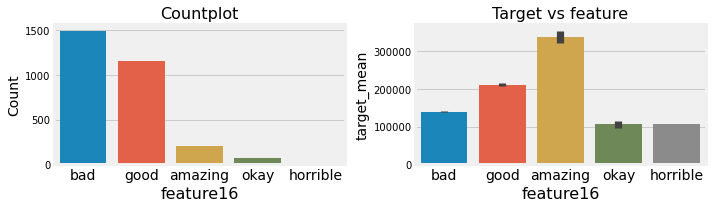

In [16]:
for feature in features[features.nominal].sort_index().index:
    if feature=='target':
        continue
        
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    
    sns.countplot(data=df, x=feature, ax=axes[0])
    axes[0].set_title('Countplot', fontsize=16)
    if feature=='feature15':
        axes[0].tick_params(axis='x', labelsize=14, rotation=25)
    else:
        axes[0].tick_params(axis='x', labelsize=14)
    axes[0].tick_params(axis='y', labelsize=10)
    axes[0].set_xlabel(xlabel=feature, fontsize=16)
    axes[0].set_ylabel(ylabel='Count', fontsize=14)
    
    sns.barplot(data=df, x=feature, y=df.target, ax=axes[1])
    axes[1].set_title('Target vs feature', fontsize=16)
    if feature=='feature15':
        axes[1].tick_params(axis='x', labelsize=14, rotation=25)
    else:
        axes[1].tick_params(axis='x', labelsize=14)
    axes[1].tick_params(axis='y', labelsize=10)
    axes[1].set_xlabel(xlabel=feature, fontsize=16)
    axes[1].set_ylabel(ylabel='target_mean', fontsize=14)
    
    plt.tight_layout()
    plt.show()

`'Feature13'`

Frequency issues indicated by the plot require further inspection.

In [17]:
df.feature13.value_counts()

red       2677
blue       187
green       50
yellow       8
pink         1
Name: feature13, dtype: int64

In [18]:
df['feature13'] = df['feature13'].replace({'green': 'other', 'yellow': 'other', 'pink': 'other'})
features.loc['feature13', 'nunique'] = 3

`'Feature15'`

In [19]:
df.feature15.value_counts()

NA          1417
good         744
bad          598
okay          75
horrible      46
amazing       43
Name: feature15, dtype: int64

Excluding 1,422 rows to classify `'feature15'` as ordinal seems outrageous. Instead, we will address this issue by weakening the native scale of this variable to nominal, so effectively `'feature15'` remains nominal.

`'Feature16'`

This feature is ordinal, despite initial 'object' dtype.

In [20]:
# transforming feature16 into ordinal scale
mapping = {
    "horrible": 1,
    "bad": 2,
    "okay": 3,
    "good": 4,
    "amazing": 5
    }

df['feature16'] = df['feature16'].map(mapping)

# features dataframe update will follow
features.loc['feature16', 'nominal']=False
features.loc['feature16', 'ordinal']=True
features.loc['feature16', 'dtype']= df['feature16'].dtype

In [21]:
df.shape

(2923, 22)

## Train / Test Split

**Dataset Summary**

In [22]:
features

,dtype,nunique,NaN_count,min,25%,50%,75%,max,mean,std_dev,continous,ordinal,nominal
feature,,,,,,,,,,,,,
feature07,int64,1292,0,334.00,1126.00,1442.00,1742.00,5642.00,1499.03,504.80,True,False,False
feature05,int64,1083,0,334.00,876.00,1084.00,1385.50,5095.00,1159.71,392.18,True,False,False
feature04,float64,1058,0,0.00,793.00,990.00,1302.00,6110.00,1052.14,440.43,True,False,False
target,int64,1031,0,12789.00,129500.00,160000.00,213500.00,755000.00,180806.77,79915.96,True,False,False
feature22,int64,635,0,0.00,0.00,0.00,703.00,2065.00,334.63,427.30,True,False,False
feature02,float64,603,0,0.00,320.00,480.00,576.00,1488.00,472.86,214.86,True,False,False
feature10,int64,118,0,1872.00,1954.00,1973.00,2001.00,2010.00,1971.34,30.25,True,False,False
feature23,int64,61,0,1950.00,1965.00,1993.00,2004.00,2010.00,1984.26,20.87,True,False,False
feature06,int64,14,0,2.00,5.00,6.00,7.00,15.00,6.44,1.57,False,True,False


In [23]:
df.sample(7)

,target,feature01,feature02,feature04,feature05,feature06,feature07,feature08,feature09,feature10,feature10.1,feature13,feature14,feature15,feature16,feature17,feature18,feature19,feature20,feature21,feature22,feature23
295,266500,1.00,252.00,1152.00,1188,9,2340,7,9,1941,2,red,2,good,4,4,1,5,2010,0,1152,2006
1417,95000,1.00,200.00,616.00,616,5,1111,5,6,1941,1,red,0,NA,2,3,1,3,2008,0,495,1950
1402,256000,2.00,529.00,1364.00,1663,6,1663,4,6,1954,1,red,2,good,4,2,1,3,2008,0,0,1994
2356,162900,2.00,528.00,832.00,832,8,1664,7,5,1976,2,red,1,bad,2,4,1,3,2006,1,832,1976
1296,155000,2.00,828.00,884.00,884,8,1436,6,6,1940,2,red,2,good,2,3,2,5,2008,0,552,1950
2577,148000,1.00,300.00,1058.00,1370,6,1370,5,6,1956,1,red,1,bad,2,3,1,2,2006,0,0,1956
1905,165000,2.00,540.00,816.00,1127,9,1977,6,6,1964,1,red,1,bad,2,4,1,6,2007,1,850,1978


**Train / Test Split**

In [24]:
y = df['target']
X = df.drop('target', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Statistical Interference

In [25]:
X_train.shape, X_test.shape

((2338, 21), (585, 21))

In [26]:
# continous features
for feature in features[features.continous].index:
    if feature=='target':
        continue
    # features found to be insignificant are excluded
    if scipy.stats.pearsonr(y_train, X_train[feature])[1] > 0.05:
        X_train = X_train.drop(feature, axis=1)
        X_test = X_test.drop(feature, axis=1)
        features = features.loc[features.index != feature]
        print('{} has been dropped.'.format(feature))

In [27]:
# ordinal features
for feature in features[features.ordinal].index:
    # features found to be insignificant are excluded
    if scipy.stats.spearmanr(y_train, X_train[feature])[1] > 0.05:
        X_train = X_train.drop(feature, axis=1)
        X_test = X_test.drop(feature, axis=1)
        features = features.loc[features.index != feature]
        print('{} has been dropped.'.format(feature))

feature20 has been dropped.


In [28]:
# Some useful data arrangements
df_train = pd.concat([X_train, y_train], axis=1)

In [29]:
# nominal features
for feature in features[features.nominal].index:
    print(feature, X_train[feature].unique())

feature15 ['NA' 'okay' 'good' 'bad' 'amazing' 'horrible']
feature13 ['red' 'other' 'blue']


In [30]:
# feature15 is significant (pvalue < 0.05)
stats.kruskal(df_train.loc[df_train['feature15']=='horrible', 'target'],
              df_train.loc[df_train['feature15']=='bad', 'target'],
              df_train.loc[df_train['feature15']=='okay', 'target'],
              df_train.loc[df_train['feature15']=='good', 'target'],
              df_train.loc[df_train['feature15']=='amazing', 'target'],
              df_train.loc[df_train['feature15']=='NA', 'target'])

KruskalResult(statistic=750.499713074493, pvalue=5.897085643336894e-160)

In [31]:
# feature13 is significant (pvalue < 0.05)
stats.kruskal(df_train.loc[df_train['feature13']=='red', 'target'],
              df_train.loc[df_train['feature13']=='blue', 'target'],
              df_train.loc[df_train['feature13']=='other', 'target'])

KruskalResult(statistic=209.752207918301, pvalue=2.8371791983778814e-46)

In [32]:
X_train.shape, X_test.shape

((2338, 20), (585, 20))

## Correlations
Colinearity is present in our dataset.

In [33]:
# some data manitulation that is useful here
row_to_move = features.loc['target']
features = features.drop('target')
features = pd.concat([row_to_move.to_frame().T, features])
features.loc['target','ordinal']=True
features.loc['target','nominal']=True

### Continous features

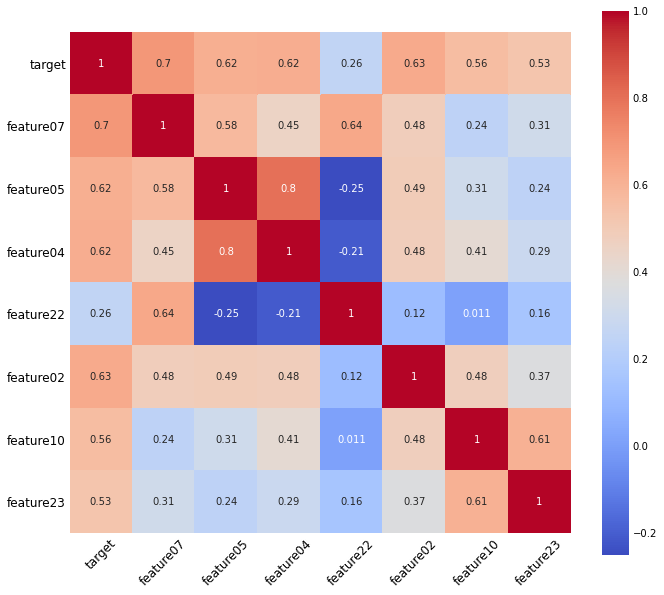

In [34]:
# Pearson coeff heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(df_train[features[features.continous].index].corr(), annot=True, square=True, cmap='coolwarm')
plt.tick_params(axis='x', labelsize=12, rotation=45)
plt.tick_params(axis='y', labelsize=12, rotation=0)
plt.show()

### Ordinal features

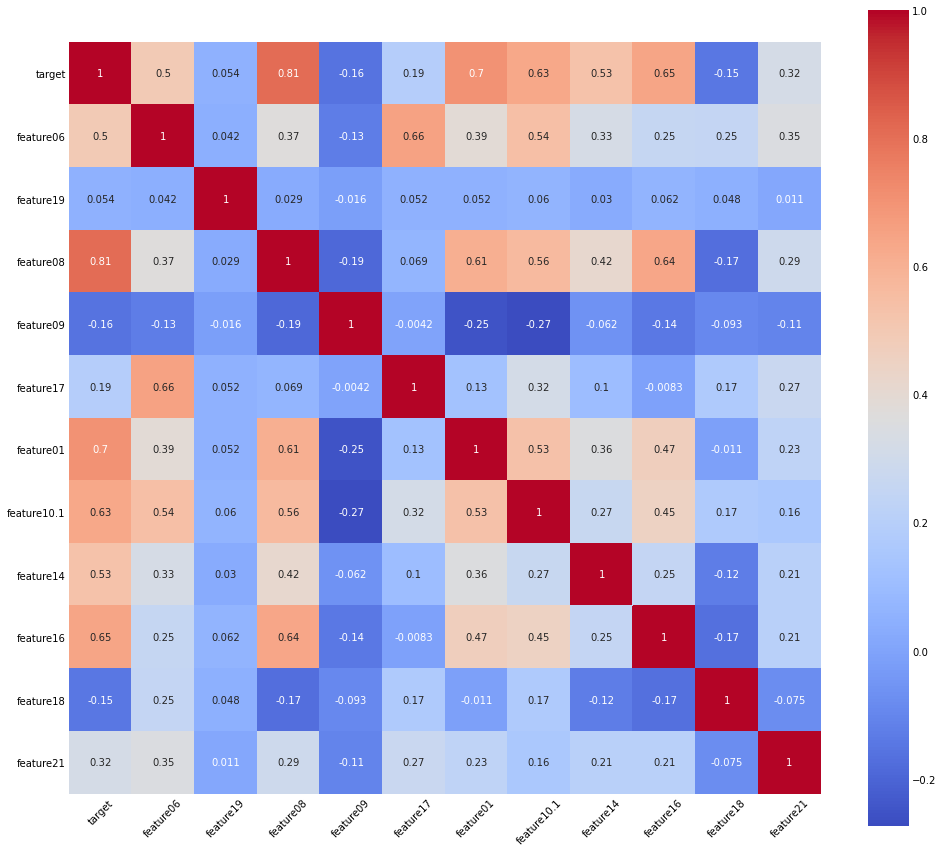

In [35]:
# Spearman coeff heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(df_train[features[features.ordinal].index].corr(method='spearman'), annot=True, square=True, cmap='coolwarm')
plt.tick_params(axis='x', labelsize=10, rotation=45)
plt.tick_params(axis='y', labelsize=10, rotation=0)
plt.show()

## Data Preparation and Dimentionality Reduction
Due to collinearity among the features and the necessity of employing dummy variables, `PCA` will be applied. The following data preparation scheme will be conducted for this dataset: `StandarScaler` for continuous features, `MinMaxScaler` for ordinal features, and `dummy variables` for nominal features. We are interested in the number of principal components that retain at least 95% of the original variability. We will now apply PCA to our training data to determine the desired number of components, as this parameter needs to be specified downstream in our pipelines.

In [36]:
features = features.loc[features.index != 'target']

prep = make_column_transformer((StandardScaler(), features[features.continous].index), 
                               (MinMaxScaler(), features[features.ordinal].index),
                               (OneHotEncoder(drop='first'), features[features.nominal].index))

df_transformed = prep.fit_transform(X_train)

pca = PCA(n_components=15, svd_solver='full')
pca.fit(df_transformed)

explained_variance_ratio = 0
components=0
while explained_variance_ratio<0.95:
    explained_variance_ratio += pca.explained_variance_ratio_[components]
    components += 1
print('Suggested number of principal components: {}'.format(components + 1))

Suggested number of principal components: 9


### Training data summarization

In [37]:
X_train.columns

Index(['feature01', 'feature02', 'feature04', 'feature05', 'feature06',
       'feature07', 'feature08', 'feature09', 'feature10', 'feature10.1',
       'feature13', 'feature14', 'feature15', 'feature16', 'feature17',
       'feature18', 'feature19', 'feature21', 'feature22', 'feature23'],
      dtype='object')

In [38]:
features.index

Index(['feature07', 'feature05', 'feature04', 'feature22', 'feature02',
       'feature10', 'feature23', 'feature06', 'feature19', 'feature08',
       'feature09', 'feature17', 'feature01', 'feature15', 'feature10.1',
       'feature14', 'feature16', 'feature13', 'feature18', 'feature21'],
      dtype='object')

In [39]:
X_train.shape, y_train.shape

((2338, 20), (2338,))

# 3) Machine Learning with sklearn

## ML Setup

In [40]:
# pipelining data preparation, dimentionality reduction, and target estimators
prep = make_column_transformer((StandardScaler(), features[features.continous].index), 
                               (MinMaxScaler(), features[features.ordinal].index),
                               (OneHotEncoder(drop='first'), features[features.nominal].index))
pipelines = {
    'linreg':make_pipeline(prep, PCA(n_components=9, svd_solver='full'), LinearRegression()),
    'gbr':make_pipeline(prep, PCA(n_components=9, svd_solver='full'), GradientBoostingRegressor()),
    'sgd':make_pipeline(prep, PCA(n_components=9, svd_solver='full'), SGDRegressor()),
    'enet':make_pipeline(prep, PCA(n_components=9, svd_solver='full'), ElasticNet())
    }

In [41]:
# hyperparameter space to be searched
hypergrid = {
    'linreg': {
        'linearregression__fit_intercept':[True, False]
    },
    'gbr': {
        'gradientboostingregressor__learning_rate':[0.001, 0.01, 0.1, 0.2, 0.5],
        'gradientboostingregressor__warm_start':[True, False]
        
    },
    'sgd': {
        'sgdregressor__alpha':[0.0001, 0.001, 0.01],
        'sgdregressor__warm_start':[True, False]
    },
    'enet': {
        'elasticnet__alpha':[33, 66, 100, 133, 166],
        'elasticnet__warm_start':[True, False],
        'elasticnet__l1_ratio':[0.001, 0.1, 0.2, 0.5, 0.66, 0.83, 0.999]
    },
    }

## Training

In [42]:
%%time
models_r2 = {}
models_mae = {}
for algo, pipeline in pipelines.items():
    model_r2 = GridSearchCV(pipeline, hypergrid[algo], cv=10, scoring='r2')
    model_mae = GridSearchCV(pipeline, hypergrid[algo], cv=10, scoring='neg_mean_absolute_error')
    model_r2.fit(X_train,y_train)
    model_mae.fit(X_train,y_train)
    models_r2[algo] = model_r2
    models_mae[algo] = model_mae

CPU times: user 8min 41s, sys: 15.7 s, total: 8min 56s
Wall time: 3min 8s


## Performance (training dataset)

In [43]:
train_results = {
    'R2': {algo: round(model.best_score_, 3) for algo, model in models_r2.items()},
    'MAE': {algo: abs(round(model.best_score_, 3)) for algo, model in models_mae.items()}
}

print('\ntarget_min: {}, target_mean: {}, target_max: {}, target_std: {}'.format(y_train.describe().iloc[3],
                                                                               round(y_train.describe().iloc[1], 2),
                                                                               y_train.describe().iloc[-1],
                                                                               round(y_train.describe().iloc[2], 2)))
train_results = pd.DataFrame(train_results)
train_results.sort_values(by='R2', ascending=False)


target_min: 12789.0, target_mean: 180359.12, target_max: 755000.0, target_std: 79156.88


,R2,MAE
gbr,0.85,19776.92
sgd,0.74,25078.51
linreg,0.74,24993.06
enet,0.74,24791.15


## Test Sample Performance

In [44]:
X_test.shape, y_test.shape

((585, 20), (585,))

In [45]:
r2_test_results = {}
mae_test_results = {}

for algo in models_r2.keys():
    y_pred_r2 = models_r2[algo].predict(X_test)
    y_pred_mae = models_mae[algo].predict(X_test)
    r2_test_results[algo] = round(r2_score(y_test, y_pred_r2), 3)
    mae_test_results[algo] = abs(round(mean_absolute_error(y_test, y_pred_mae), 3))

test_results = pd.DataFrame({
    'R2': pd.Series(r2_test_results),
    'MAE': pd.Series(mae_test_results)
})

print('\ntarget_min: {}, target_mean: {}, target_max: {}, target_std: {}'.format(y_test.describe().iloc[3],
                                                                               round(y_test.describe().iloc[1], 2),
                                                                               y_train.describe().iloc[-1],
                                                                               round(y_test.describe().iloc[2], 2)))
test_results.sort_values(by='R2', ascending=False)


target_min: 13100.0, target_mean: 182595.85, target_max: 755000.0, target_std: 82925.81


,R2,MAE
gbr,0.88,19207.09
sgd,0.82,24486.71
linreg,0.81,24556.15
enet,0.81,24276.40


# 4) Deep-Learning with tf.keras

In [46]:
X_train.shape, y_train.shape

((2338, 20), (2338,))

### Data preparation

In [47]:
# we will rephrase data preparation scheme for clarity
prep = make_column_transformer((StandardScaler(), features[features.continous].index), 
                               (MinMaxScaler(), features[features.ordinal].index),
                               (OneHotEncoder(drop='first'), features[features.nominal].index))

data_pipe = make_pipeline(prep, PCA(n_components=9, svd_solver='full'))
X_train_transformed = data_pipe.fit_transform(X_train)

In [48]:
X_train_transformed.shape

(2338, 9)

### Network architecture

In [49]:
# neural network architecture definition
model = Sequential([
    tf.keras.layers.Dense(64, input_shape=(9,), activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1) 
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                640       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,753
Trainable params: 2,753
Non-trainable params: 0
_________________________________________________________________


## Training

In [50]:
# compilation
model.compile(optimizer=Adam(learning_rate=0.005), loss='mean_squared_error', metrics=['mae'])

# callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.35, patience=20, min_lr=0.0000005)

# backpropagation
training = model.fit(x=X_train_transformed, y=y_train, validation_split=0.1, batch_size=64, epochs=5000, shuffle=True, verbose=0, callbacks=[early_stopping, reduce_lr])

# training performance
train_mae = training.history['mae']
val_mae = training.history['val_mae']
print(f"Final training MAE: {train_mae[-1]}")
print(f"Final validation MAE: {val_mae[-1]}")

Final training MAE: 22769.775390625
Final validation MAE: 25027.71875


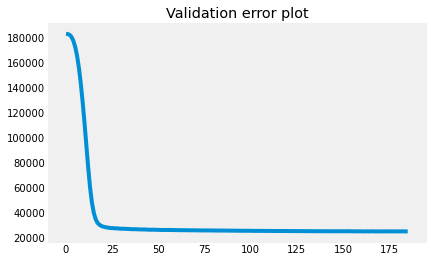

In [51]:
plt.plot(val_mae)
plt.title('Validation error plot')
plt.grid(False) 
plt.show()

## Test Sample Performance

In [52]:
X_test.shape, y_test.shape

((585, 20), (585,))

In [53]:
y_pred = model.predict(data_pipe.fit_transform(X_test), verbose=0)
y_pred.shape

(585, 1)

In [54]:
test_results.loc['NeuralNet', 'R2'] = round(r2_score(y_test, y_pred), 3)
test_results.loc['NeuralNet', 'MAE'] = abs(round(mean_absolute_error(y_test, y_pred), 3))
test_results.loc['NeuralNet']

R2        0.84
MAE   23321.08
Name: NeuralNet, dtype: float64

# 5) Models Comparison

In [55]:
print('\ntarget_min: {}, target_mean: {}, target_max: {}, target_std: {}'.format(y_test.describe().iloc[3],
                                                                               round(y_test.describe().iloc[1], 2),
                                                                               y_train.describe().iloc[-1],
                                                                               round(y_test.describe().iloc[2], 2)))
test_results.sort_values(by='R2', ascending=False)


target_min: 13100.0, target_mean: 182595.85, target_max: 755000.0, target_std: 82925.81


,R2,MAE
gbr,0.88,19207.09
NeuralNet,0.84,23321.08
sgd,0.82,24486.71
linreg,0.81,24556.15
enet,0.81,24276.40


## Best model

In [56]:
test_results.loc['gbr']

R2        0.88
MAE   19207.09
Name: gbr, dtype: float64

In [57]:
models_r2['gbr'].best_params_

{'gradientboostingregressor__learning_rate': 0.1,
 'gradientboostingregressor__warm_start': False}

In [58]:
models_r2['gbr']

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('standardscaler',
                                                                         StandardScaler(),
                                                                         Index(['feature07', 'feature05', 'feature04', 'feature22', 'feature02',
       'feature10', 'feature23'],
      dtype='object')),
                                                                        ('minmaxscaler',
                                                                         MinMaxScaler(),
                                                                         Index(['feature06', 'feature19', 'feature08', 'feature09', 'feature17',
       'feature01...
                                                                        ('onehotencoder',
                                                                         OneHotEncoder(drop='first'),
                                                                         Index(['feature15', 'feature13'], dtype='object'))])),
                                       ('pca',
                                        PCA(n_components=9, svd_solver='full')),
                                       ('gradientboostingregressor',
                                        GradientBoostingRegressor())]),
             param_grid={'gradientboostingregressor__learning_rate': [0.001,
                                                                      0.01, 0.1,
                                                                      0.2,
                                                                      0.5],
                         'gradientboostingregressor__warm_start': [True,
                                                                   False]},
             scoring='r2')